# IDX-Trade Foreign Flow Exploration

Outcome-blind historical exploration of the accepted Foreign Flow Representation V2 artifact. This notebook is read-only, does not train a model, and does not access protected forward outcomes.


## 1. Scope and reading guide

The notebook uses the frozen offline Representation V2 parquet, its causal market context, and the official historical IDX foreign-flow archive named by the input manifest. Missing values remain missing and are not converted to zero. All observations are descriptive and contemporaneous; they are not a trading backtest or a promotion decision.

The single configuration cell below controls the artifact root and ticker drilldown. The default ticker is BBCA. Case-study names are selected from the largest observed canonical shock magnitudes, with FUJI, CASA, JGLE, and PSKT expected when present.


In [1]:
from pathlib import Path
import hashlib
import json
import os
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ARTIFACT_ROOT = Path(os.environ.get("IDX_TRADE_FOREIGN_FLOW_ROOT", r"D:\\Documents\\Project\\idx-trade-foreign-flow-representation-v2-20260815-001"))
TICKER = os.environ.get("IDX_TRADE_FOREIGN_FLOW_TICKER", "BBCA").upper()
CASE_STUDY_TICKERS = ["FUJI", "CASA", "JGLE", "PSKT"]
IHSG_CONTEXT_STATUS = "IHSG_CONTEXT_UNAVAILABLE"
IHSG_CONTEXT_REASON = (
    "Local inspection found only date-sparse official IDX index snapshots and month fragments, "
    "plus synthetic test fixtures. No continuous, canonical, date-aligned IHSG series is "
    "accepted for this exploratory archive."
)
assert ARTIFACT_ROOT.is_dir(), f"Artifact root not found: {ARTIFACT_ROOT}"

def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

manifest = json.loads((ARTIFACT_ROOT / "manifest.json").read_text(encoding="utf-8"))
input_manifest = json.loads((ARTIFACT_ROOT / "input_manifest.json").read_text(encoding="utf-8"))
audit_summary = json.loads((ARTIFACT_ROOT / "audit_summary.json").read_text(encoding="utf-8"))
FLOW_ARCHIVE_ROOT = Path(input_manifest["archive_manifest"]["archive_manifest_path"]).parent
REP_PATH = ARTIFACT_ROOT / "foreign_flow_representation_v2.parquet"
CONTEXT_PATH = ARTIFACT_ROOT / "causal_market_context.parquet"

rep = pd.read_parquet(REP_PATH)
context = pd.read_parquet(CONTEXT_PATH)
rep["feature_session"] = pd.to_datetime(rep["feature_session"])
rep["flow_through_session"] = pd.to_datetime(rep["flow_through_session"])
context["date"] = pd.to_datetime(context["date"])

flow_files = sorted((FLOW_ARCHIVE_ROOT / "sessions").glob("*/foreign_flow.parquet"))
flow_parts = [pd.read_parquet(path) for path in flow_files]
flow = pd.concat(flow_parts, ignore_index=True)
flow["session_date"] = pd.to_datetime(flow["session_date"])
flow = flow.loc[flow["session_date"].between(rep["flow_through_session"].min(), context["date"].max())].copy()
flow = flow.drop_duplicates(["ticker", "session_date"], keep="first")

context_for_join = context.rename(columns={"date": "flow_through_session"})
panel = rep.merge(context_for_join, on=["ticker", "flow_through_session"], how="left", validate="many_to_one")
panel = panel.merge(flow[["ticker", "session_date", "foreign_buy", "foreign_sell", "foreign_net", "unit", "source"]], left_on=["ticker", "flow_through_session"], right_on=["ticker", "session_date"], how="left", validate="one_to_one")
panel["flow_per_market_value"] = panel["foreign_net"] / panel["regular_market_value"].where(panel["regular_market_value"] > 0)

FEATURES = [
    "foreign_participation_1", "foreign_participation_mean_5",
    "foreign_flow_shock_1", "foreign_flow_shock_mean_5",
    "foreign_flow_shock_mean_20", "foreign_flow_shock_percentile_120",
    "xs_rank_foreign_flow_shock_1", "xs_rank_foreign_flow_shock_mean_5",
    "xs_rank_foreign_flow_shock_mean_20", "foreign_weighted_persistence_5",
    "foreign_weighted_persistence_20", "foreign_signed_streak_10",
    "foreign_flow_acceleration_5_20", "foreign_flow_price_divergence_5",
    "foreign_flow_price_divergence_20",
]

plt.rcParams.update({
    "figure.figsize": (12, 5), "figure.dpi": 120,
    "axes.titlesize": 14, "axes.labelsize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "axes.grid": True,
    "grid.alpha": 0.22, "font.family": "DejaVu Sans",
})
BLUE = "#2f6fbb"
BLUE_DARK = "#164a7b"
ORANGE = "#e58f2a"
PURPLE = "#7057a3"
RED = "#c94c4c"
GRAY = "#3d4652"

provenance = pd.DataFrame([
    {"role": "Representation V2 parquet", "path": str(REP_PATH), "sha256": sha256_file(REP_PATH)},
    {"role": "Causal market context parquet", "path": str(CONTEXT_PATH), "sha256": sha256_file(CONTEXT_PATH)},
    {"role": "Official flow archive manifest", "path": str(FLOW_ARCHIVE_ROOT / "archive_manifest.json"), "sha256": sha256_file(FLOW_ARCHIVE_ROOT / "archive_manifest.json")},
])
display(Markdown(f"**Artifact root:** `{ARTIFACT_ROOT}` | **Feature rows:** {len(rep):,} | **Flow rows used:** {len(flow):,} | **Configured ticker:** `{TICKER}`"))
display(provenance)
display(Markdown(f"**IHSG context:** `{IHSG_CONTEXT_STATUS}`. {IHSG_CONTEXT_REASON}"))


**Artifact root:** `D:\Documents\Project\idx-trade-foreign-flow-representation-v2-20260815-001` | **Feature rows:** 1,102,400 | **Flow rows used:** 1,106,490 | **Configured ticker:** `BBCA`

,role,path,sha256
0,Representation V2 parquet,D:\Documents\Project\idx-trade-foreign-flow-re...,0c2212a166115b2f5b974b93096ea06b222b7451d70fa7...
1,Causal market context parquet,D:\Documents\Project\idx-trade-foreign-flow-re...,085d7628024c3792bd3a021320ac5377b3e869bcb4ad2e...
2,Official flow archive manifest,D:\Documents\Project\idx-trade-foreign-flow-hi...,fe9b8f64b6915f252502d114a06b107f3f9ea9b50205b0...


**IHSG context:** `IHSG_CONTEXT_UNAVAILABLE`. Local inspection found only date-sparse official IDX index snapshots and month fragments, plus synthetic test fixtures. No continuous, canonical, date-aligned IHSG series is accepted for this exploratory archive.

## 2. Dataset overview

The accepted Representation V2 artifact covers feature sessions from the next official session after each flow-through session. Availability is reported as fully available, partial, or all missing. Partial and missing rows are part of the data contract, not silent zero-flow observations.


,measure,value
0,feature rows,"1,102,400"
1,tickers,979
2,feature sessions,"1,259"
3,fully available rows,"318,592"
4,partial rows,"783,240"
5,all missing rows,568
6,official flow rows used,"1,106,490"


,status,rows
0,PARTIAL,783240
1,FULLY_AVAILABLE,318592
2,ALL_MISSING,568


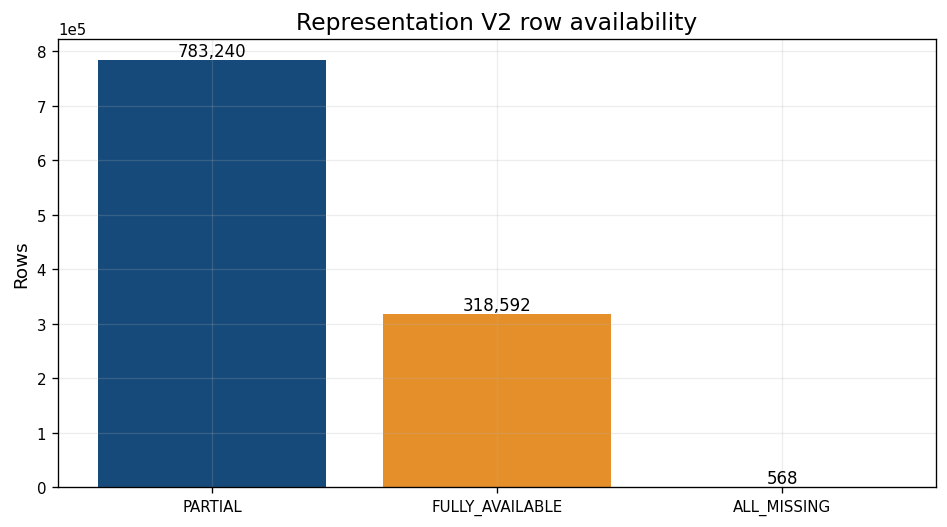

Feature coverage: `2021-04-30` to `2026-07-31`. The artifact status is `FOREIGN_FLOW_REPRESENTATION_V2_OFFLINE_CENSUS_COMPLETE`.

In [2]:
availability = pd.read_csv(ARTIFACT_ROOT / "row_availability.csv")
availability_summary = availability["availability_status"].value_counts().rename_axis("status").reset_index(name="rows")
coverage_summary = pd.DataFrame({
    "measure": ["feature rows", "tickers", "feature sessions", "fully available rows", "partial rows", "all missing rows", "official flow rows used"],
    "value": [len(rep), rep["ticker"].nunique(), rep["feature_session"].nunique(), audit_summary["availability"]["fully_available_rows"], audit_summary["availability"]["partial_rows"], audit_summary["availability"]["all_missing_rows"], input_manifest["flow_rows_used"]],
})
display(coverage_summary.assign(value=coverage_summary["value"].map(lambda value: f"{value:,}")))
display(availability_summary)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = [BLUE_DARK, ORANGE, RED]
ax.bar(availability_summary["status"], availability_summary["rows"], color=colors[:len(availability_summary)])
ax.set_title("Representation V2 row availability")
ax.set_ylabel("Rows")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
for index, value in enumerate(availability_summary["rows"]): ax.text(index, value, f"{value:,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

display(Markdown(f"Feature coverage: `{rep.feature_session.min():%Y-%m-%d}` to `{rep.feature_session.max():%Y-%m-%d}`. The artifact status is `{manifest.get('status', 'not stated')}`."))


## 3. Raw foreign flow

Raw buy, sell, and net flow are read from the official IDX Stock Summary-derived archive referenced by the accepted input manifest. These are summed share counts across observed ticker rows, not an economic market-wide or value-weighted foreign-flow measure. The aggregate can be affected by ticker composition, stock denomination, corporate actions, and archive coverage. The observed ticker count is a count of distinct ticker observations in the loaded archive, not a market-coverage percentage. The context parquet supplies close and regular market value, but no volume column is available in that accepted context artifact, so volume is not displayed.


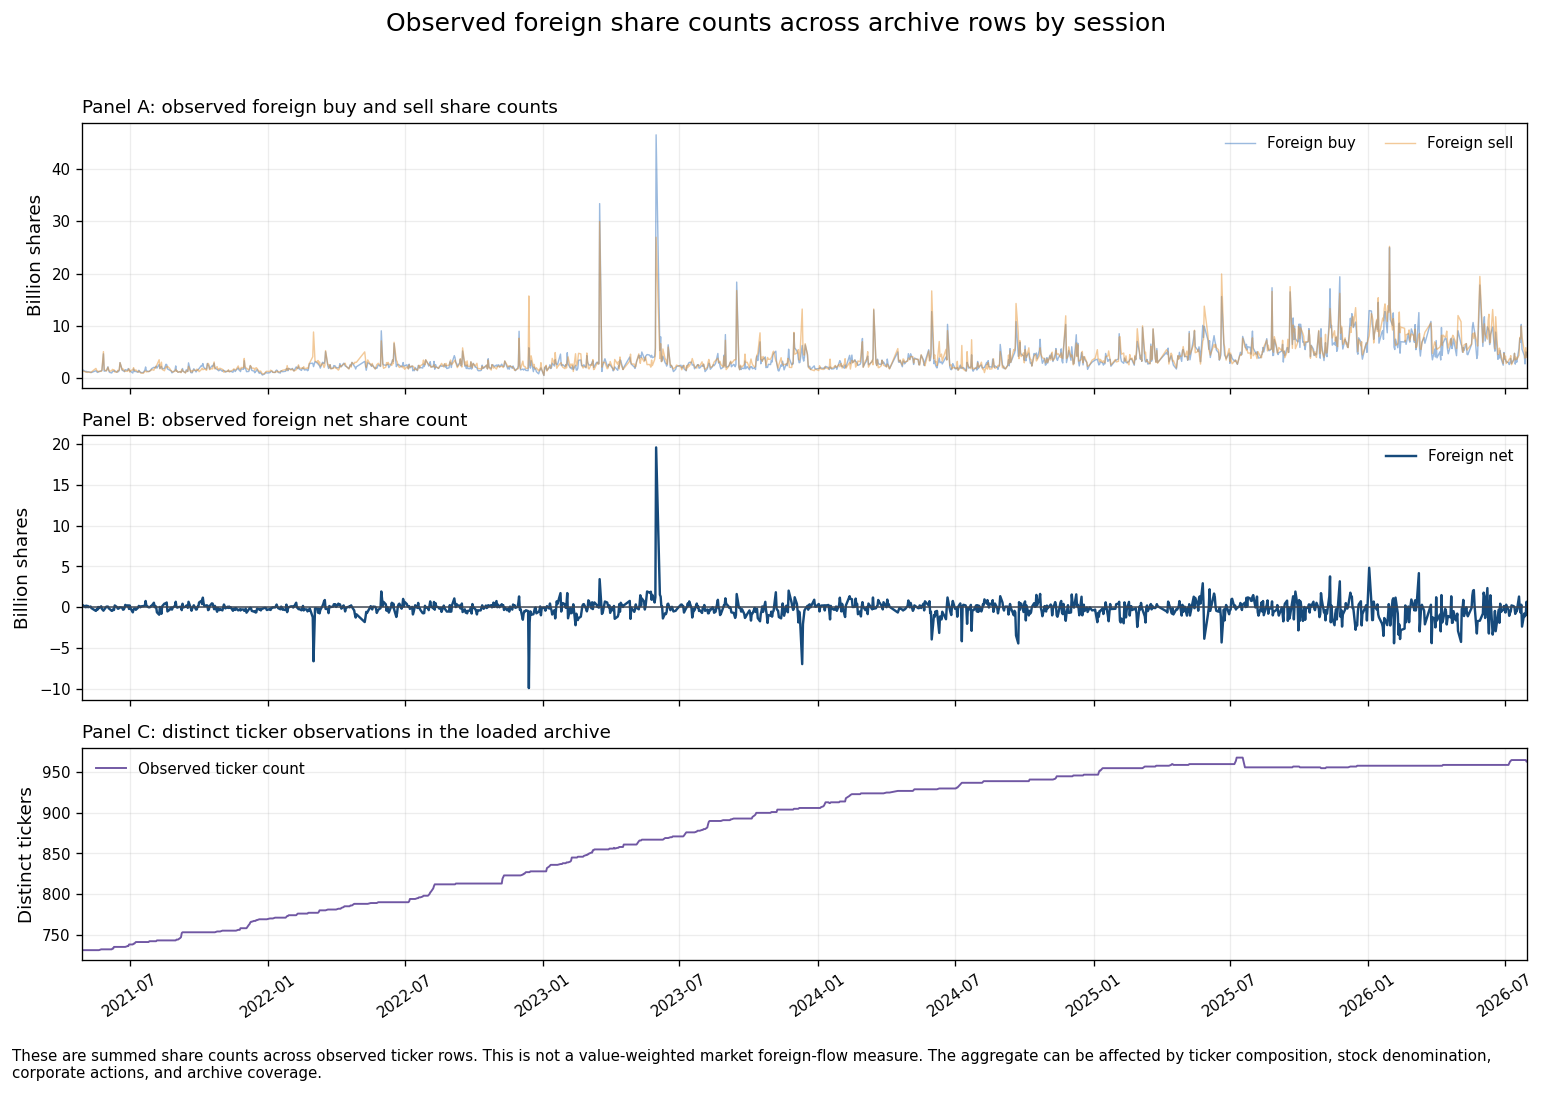

**Observed ticker count:** median `904`, range `731` to `968` distinct tickers per archive session. This is an observed row count, not a market-coverage claim.

In [3]:
raw_daily = flow.groupby("session_date", as_index=False)[["foreign_buy", "foreign_sell", "foreign_net"]].sum()
observed_counts = flow.groupby("session_date")["ticker"].nunique().rename("observed_ticker_count")
raw_daily = raw_daily.merge(observed_counts, on="session_date", how="left", validate="one_to_one")
raw_daily[["foreign_buy", "foreign_sell", "foreign_net"]] = raw_daily[["foreign_buy", "foreign_sell", "foreign_net"]] / 1_000_000_000
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, gridspec_kw={"height_ratios": [1, 1, 0.8]})
axes[0].plot(raw_daily["session_date"], raw_daily["foreign_buy"], color=BLUE, lw=0.85, alpha=0.48, label="Foreign buy")
axes[0].plot(raw_daily["session_date"], raw_daily["foreign_sell"], color=ORANGE, lw=0.85, alpha=0.48, label="Foreign sell")
axes[0].set_title("Panel A: observed foreign buy and sell share counts", loc="left", fontsize=11)
axes[0].set_ylabel("Billion shares")
axes[0].legend(ncol=2, frameon=False)
axes[1].plot(raw_daily["session_date"], raw_daily["foreign_net"], color=BLUE_DARK, lw=1.45, label="Foreign net")
axes[1].axhline(0, color=GRAY, lw=0.9)
axes[1].set_title("Panel B: observed foreign net share count", loc="left", fontsize=11)
axes[1].set_ylabel("Billion shares")
axes[1].legend(frameon=False)
axes[2].plot(raw_daily["session_date"], raw_daily["observed_ticker_count"], color=PURPLE, lw=1.15, label="Observed ticker count")
axes[2].set_title("Panel C: distinct ticker observations in the loaded archive", loc="left", fontsize=11)
axes[2].set_ylabel("Distinct tickers")
axes[2].legend(frameon=False)
for ax in axes:
    ax.grid(axis="y", alpha=0.22)
    ax.set_xlim(raw_daily["session_date"].min(), raw_daily["session_date"].max())
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].tick_params(axis="x", rotation=35)
fig.suptitle("Observed foreign share counts across archive rows by session", y=0.995, fontsize=15)
fig.text(0.01, 0.005, "These are summed share counts across observed ticker rows. This is not a value-weighted market foreign-flow measure. The aggregate can be affected by ticker composition, stock denomination, corporate actions, and archive coverage.", ha="left", va="bottom", fontsize=9, wrap=True)
plt.tight_layout(rect=[0, 0.045, 1, 0.97])
plt.show()
display(Markdown(f"**Observed ticker count:** median `{raw_daily['observed_ticker_count'].median():.0f}`, range `{raw_daily['observed_ticker_count'].min():.0f}` to `{raw_daily['observed_ticker_count'].max():.0f}` distinct tickers per archive session. This is an observed row count, not a market-coverage claim."))


### 3.1 Normalized market context

This view aggregates already accepted normalized Representation V2 fields by feature session. The line is the cross-sectional median and the band is the interquartile range among finite observations for that metric on that session. Missing observations remain missing and are not converted to zero. This is presentation aggregation only; it does not introduce a new feature or a trading signal.

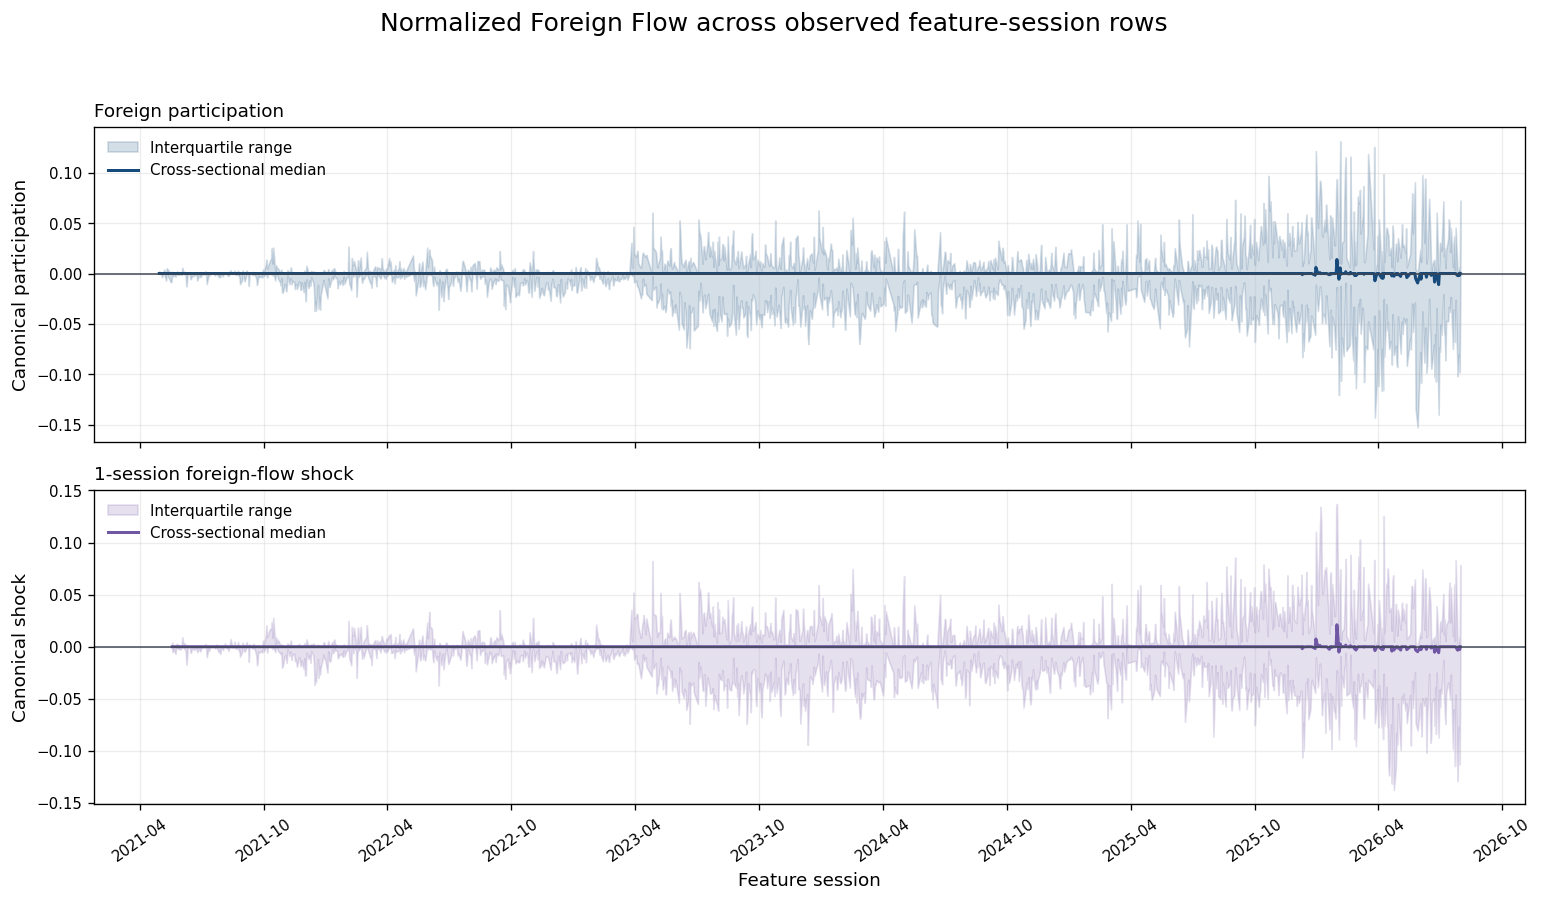

In [4]:
normalized_context = panel.groupby("feature_session").agg(
    participation_q25=("foreign_participation_1", lambda values: values.quantile(0.25)),
    participation_median=("foreign_participation_1", "median"),
    participation_q75=("foreign_participation_1", lambda values: values.quantile(0.75)),
    shock_q25=("foreign_flow_shock_1", lambda values: values.quantile(0.25)),
    shock_median=("foreign_flow_shock_1", "median"),
    shock_q75=("foreign_flow_shock_1", lambda values: values.quantile(0.75)),
).reset_index()
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
context_specs = [
    (axes[0], "participation_q25", "participation_median", "participation_q75", "Foreign participation", "Canonical participation", BLUE_DARK),
    (axes[1], "shock_q25", "shock_median", "shock_q75", "1-session foreign-flow shock", "Canonical shock", PURPLE),
]
for ax, lower, median, upper, title, ylabel, color in context_specs:
    x = normalized_context["feature_session"]
    lo = normalized_context[lower].to_numpy(dtype=float)
    mid = normalized_context[median].to_numpy(dtype=float)
    hi = normalized_context[upper].to_numpy(dtype=float)
    ax.fill_between(x, lo, hi, color=color, alpha=0.18, label="Interquartile range")
    ax.plot(x, mid, color=color, lw=1.8, label="Cross-sectional median")
    ax.axhline(0, color=GRAY, lw=0.9)
    ax.set_title(title, loc="left", fontsize=11)
    ax.set_ylabel(ylabel)
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.22)
axes[-1].set_xlabel("Feature session")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[-1].tick_params(axis="x", rotation=35)
fig.suptitle("Normalized Foreign Flow across observed feature-session rows", y=0.995, fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


## 4. Participation and normalized flow

Participation is shown using the canonical V2 participation features. The flow-per-market-value ratio is a transparent descriptive normalization made from raw net shares and causal regular market value; it is not introduced as a new model feature.


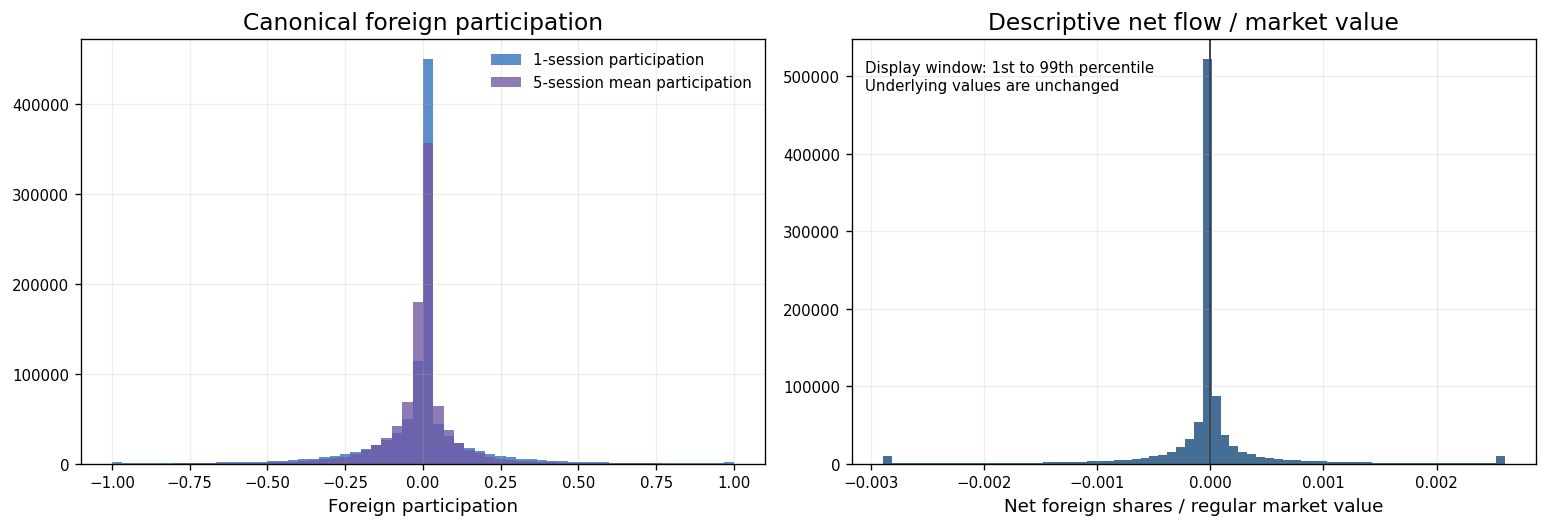

,feature_session,foreign_buy,foreign_sell,foreign_net,regular_market_value,foreign_participation_1,flow_per_market_value
1094793,2026-07-22,91404100.0,88733600.0,2670500.0,9.486642e+11,0.018283,0.000003
1095756,2026-07-23,70789600.0,68085700.0,2703900.0,7.244705e+11,0.024103,0.000004
1096719,2026-07-24,76894600.0,153110800.0,-76216200.0,1.315503e+12,-0.368127,-0.000058
1097682,2026-07-27,132816400.0,112843300.0,19973100.0,1.187569e+12,0.104337,0.000017
1098645,2026-07-28,93658200.0,78311300.0,15346900.0,7.838218e+11,0.122635,0.000020
1099608,2026-07-29,91576700.0,88577500.0,2999200.0,7.686122e+11,0.024400,0.000004
1100571,2026-07-30,98791700.0,83709400.0,15082300.0,7.636120e+11,0.123242,0.000020
1101534,2026-07-31,125681600.0,75977600.0,49704000.0,9.747694e+11,0.325579,0.000051


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for column, label, color in [("foreign_participation_1", "1-session participation", BLUE), ("foreign_participation_mean_5", "5-session mean participation", PURPLE)]:
    values = panel[column].dropna()
    axes[0].hist(values, bins=60, color=color, alpha=0.78, label=label)
axes[0].set_title("Canonical foreign participation")
axes[0].set_xlabel("Foreign participation")
axes[0].legend(frameon=False)

normalized = panel["flow_per_market_value"].dropna()
window = normalized.clip(normalized.quantile(0.01), normalized.quantile(0.99))
axes[1].hist(window, bins=70, color=BLUE_DARK, alpha=0.8)
axes[1].axvline(0, color=GRAY, lw=1.2)
axes[1].set_title("Descriptive net flow / market value")
axes[1].set_xlabel("Net foreign shares / regular market value")
axes[1].text(0.02, 0.95, "Display window: 1st to 99th percentile\nUnderlying values are unchanged", transform=axes[1].transAxes, va="top", fontsize=9)
plt.tight_layout()
plt.show()

ticker_panel = panel.loc[panel["ticker"] == TICKER, ["feature_session", "foreign_buy", "foreign_sell", "foreign_net", "regular_market_value", "foreign_participation_1", "flow_per_market_value"]].tail(8)
display(ticker_panel)


## 5. Flow shock and tails

The three canonical shock horizons are shown together. The central plots use a 1st to 99th percentile display window only to keep the figure legible; anomaly counts and extrema use the untouched values. No winsorization is applied.


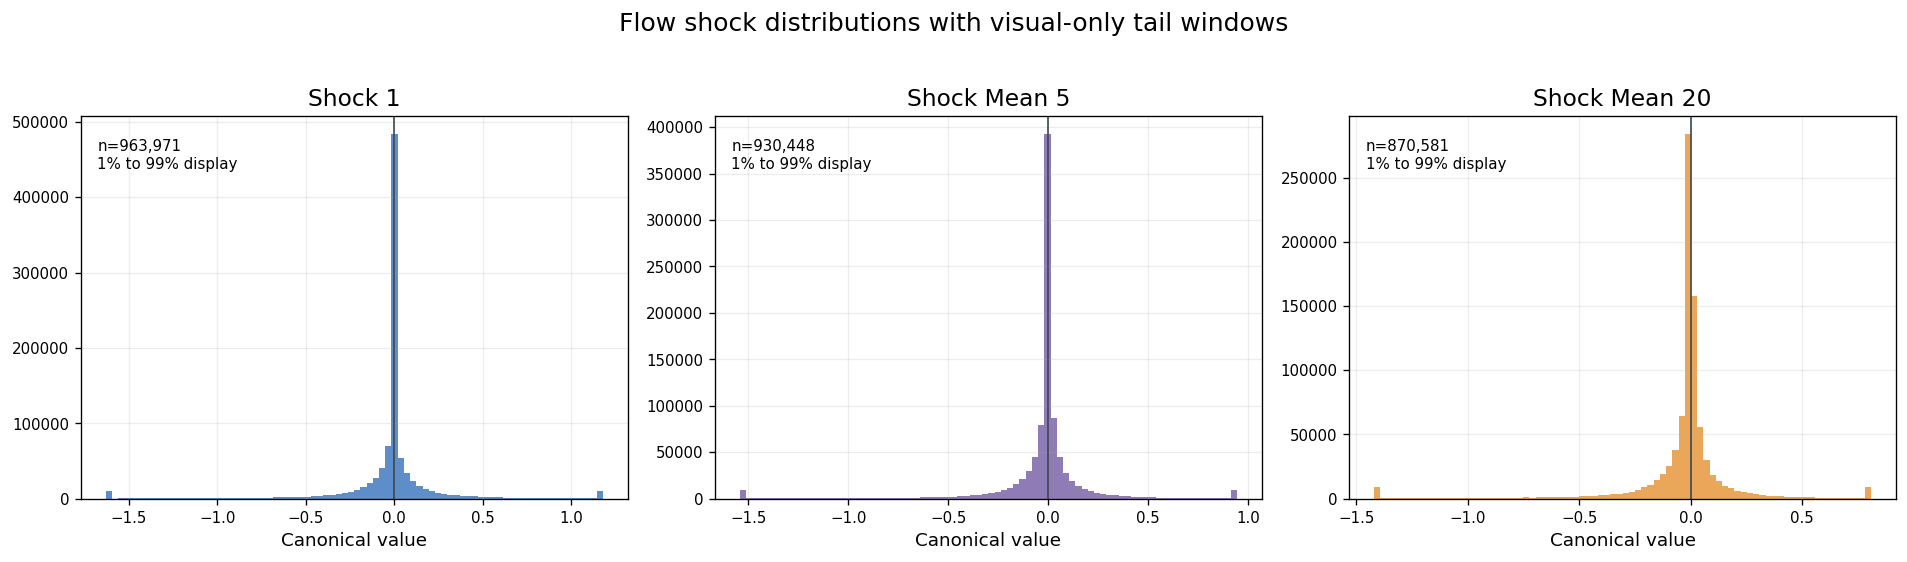

**Largest positive canonical shock values**

,ticker,feature_session,foreign_flow_shock_1
313301,FUJI,2022-12-21,62062.306900
314126,FUJI,2022-12-22,14337.621009
522360,TGRA,2023-12-19,4528.500000
88879,TURI,2021-10-27,3818.003650
461899,KREN,2023-09-14,2836.666667
784753,NICK,2025-02-28,2800.161160
73032,SULI,2021-09-27,2647.148387
312476,FUJI,2022-12-20,2533.470649


**Largest negative canonical shock values**

,ticker,feature_session,foreign_flow_shock_1
81558,CASA,2021-10-13,-41719.091451
597055,JGLE,2024-05-03,-31310.149055
82310,CASA,2021-10-14,-21154.876754
133652,PSKT,2022-01-19,-19722.120000
129802,PSKT,2022-01-12,-19438.888485
132112,PSKT,2022-01-17,-14206.242791
531783,FUJI,2024-01-08,-13926.887771
131342,PSKT,2022-01-14,-10612.604651


In [6]:
shock_columns = ["foreign_flow_shock_1", "foreign_flow_shock_mean_5", "foreign_flow_shock_mean_20"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, column, color in zip(axes, shock_columns, [BLUE, PURPLE, ORANGE]):
    values = panel[column].dropna()
    visual = values.clip(values.quantile(0.01), values.quantile(0.99))
    ax.hist(visual, bins=80, color=color, alpha=0.78)
    ax.axvline(0, color=GRAY, lw=1)
    ax.set_title(column.replace("foreign_flow_", "").replace("_", " ").title())
    ax.set_xlabel("Canonical value")
    ax.text(0.03, 0.94, f"n={len(values):,}\n1% to 99% display", transform=ax.transAxes, va="top", fontsize=9)
plt.suptitle("Flow shock distributions with visual-only tail windows", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

shock = panel[["ticker", "feature_session", "foreign_flow_shock_1"]].dropna().copy()
shock["absolute_shock"] = shock["foreign_flow_shock_1"].abs()
largest_positive = shock.nlargest(8, "foreign_flow_shock_1").drop(columns="absolute_shock")
largest_negative = shock.nsmallest(8, "foreign_flow_shock_1").drop(columns="absolute_shock")
display(Markdown("**Largest positive canonical shock values**"))
display(largest_positive)
display(Markdown("**Largest negative canonical shock values**"))
display(largest_negative)


## 6. Anomaly census

Anomalies below are a descriptive census of absolute 1-session shock. Thresholds do not imply an economic event, a data error, or a causal explanation.


,threshold,rows,tickers
0,|shock| > 1,28593,909
1,|shock| > 2,12607,854
2,|shock| > 5,4809,632
3,|shock| > 10,2458,467
4,|shock| > 20,1301,334


**Most frequent tickers with |shock| > 5**

,ticker,extreme_rows
0,BATA,76
1,FAST,61
2,KREN,58
3,BRNA,55
4,BSIM,45
5,SIPD,44
6,MSKY,43
7,INPP,43
8,MORA,43
9,LPGI,41


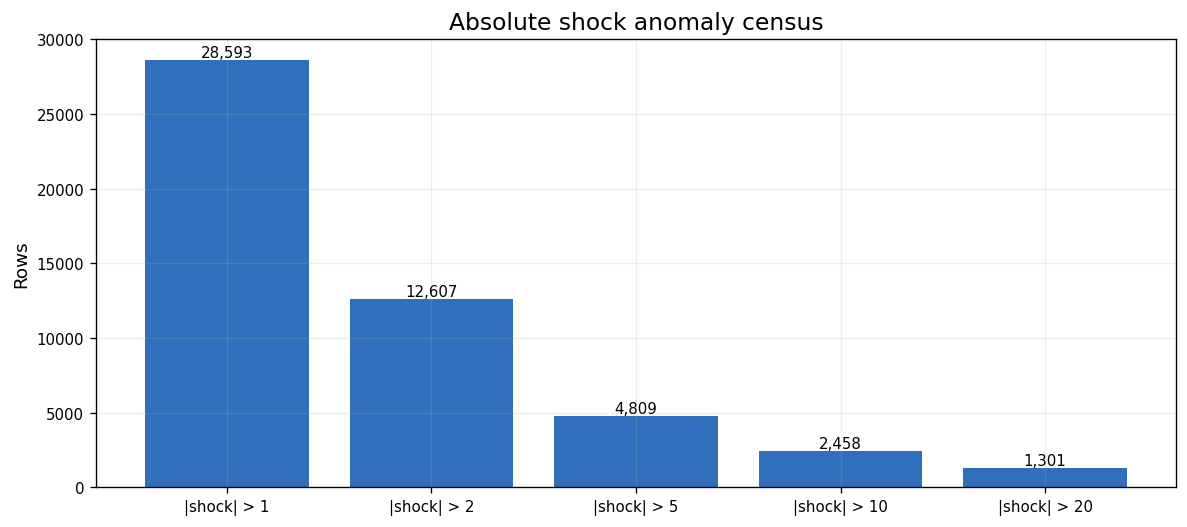

Case-study names selected from the largest untouched shock values: `FUJI, CASA, JGLE, PSKT`.

In [7]:
threshold_rows = []
for threshold in [1, 2, 5, 10, 20]:
    subset = shock.loc[shock["absolute_shock"] > threshold]
    threshold_rows.append({"threshold": f"|shock| > {threshold}", "rows": len(subset), "tickers": subset["ticker"].nunique()})
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)

frequent_extremes = (shock.loc[shock["absolute_shock"] > 5].groupby("ticker").size().sort_values(ascending=False).head(12).rename("extreme_rows").reset_index())
display(Markdown("**Most frequent tickers with |shock| > 5**"))
display(frequent_extremes)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(threshold_table["threshold"], threshold_table["rows"], color=BLUE)
ax.set_title("Absolute shock anomaly census")
ax.set_ylabel("Rows")
for index, value in enumerate(threshold_table["rows"]): ax.text(index, value, f"{value:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

case_names = list(dict.fromkeys(shock.nlargest(12, "absolute_shock")["ticker"].tolist()))
for name in CASE_STUDY_TICKERS:
    if name not in case_names and len(case_names) < 4 and name in set(panel["ticker"]): case_names.append(name)
case_names = case_names[:4]
display(Markdown(f"Case-study names selected from the largest untouched shock values: `{', '.join(case_names)}`."))


## 7. Ticker case studies

These panels show repeated extreme names in their historical context. They are descriptive case studies only. No causal claim is made about price, liquidity, announcements, or future returns.

`IHSG_CONTEXT_UNAVAILABLE`: the local candidates inspected were date-sparse official IDX index snapshots, month fragments, or synthetic test fixtures. No continuous, canonical, date-aligned IHSG series is accepted for these displayed windows, so no ticker versus IHSG rebase is plotted.

**IHSG_CONTEXT_UNAVAILABLE**. Local inspection found only date-sparse official IDX index snapshots and month fragments, plus synthetic test fixtures. No continuous, canonical, date-aligned IHSG series is accepted for this exploratory archive. No ticker versus IHSG comparison is plotted.

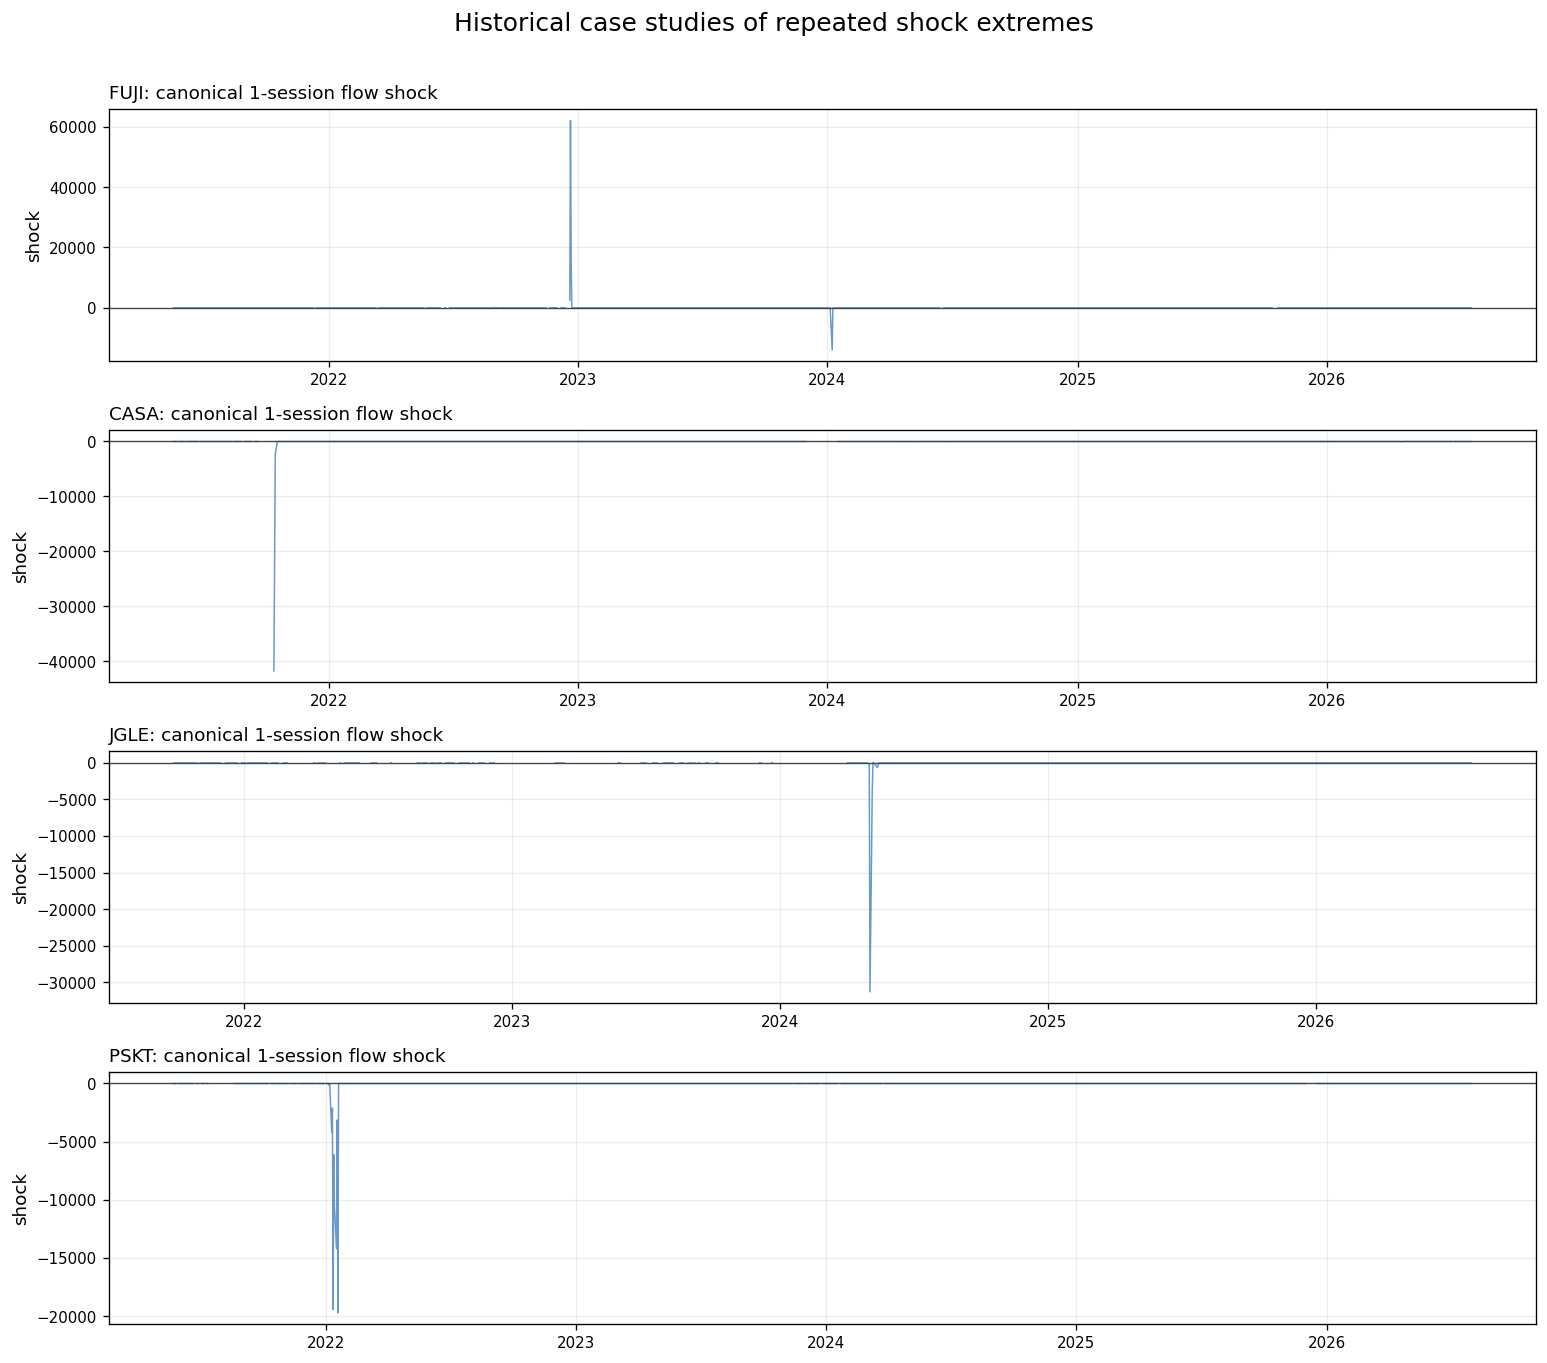

In [8]:
display(Markdown(f"**{IHSG_CONTEXT_STATUS}**. {IHSG_CONTEXT_REASON} No ticker versus IHSG comparison is plotted."))

fig, axes = plt.subplots(len(case_names), 1, figsize=(13, max(4, 2.8 * len(case_names))), sharex=False)
axes = np.atleast_1d(axes)
for ax, name in zip(axes, case_names):
    series = panel.loc[panel["ticker"] == name].sort_values("feature_session")
    ax.plot(series["feature_session"], series["foreign_flow_shock_1"], color=BLUE, lw=0.9, alpha=0.72)
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.set_title(f"{name}: canonical 1-session flow shock", loc="left", fontsize=11)
    ax.set_ylabel("shock")
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.suptitle("Historical case studies of repeated shock extremes", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()


## 8. Persistence, streak, and acceleration

Persistence and streak fields describe historical flow behavior over their stated windows. Acceleration is displayed as a distribution and is not interpreted as a predictive result.


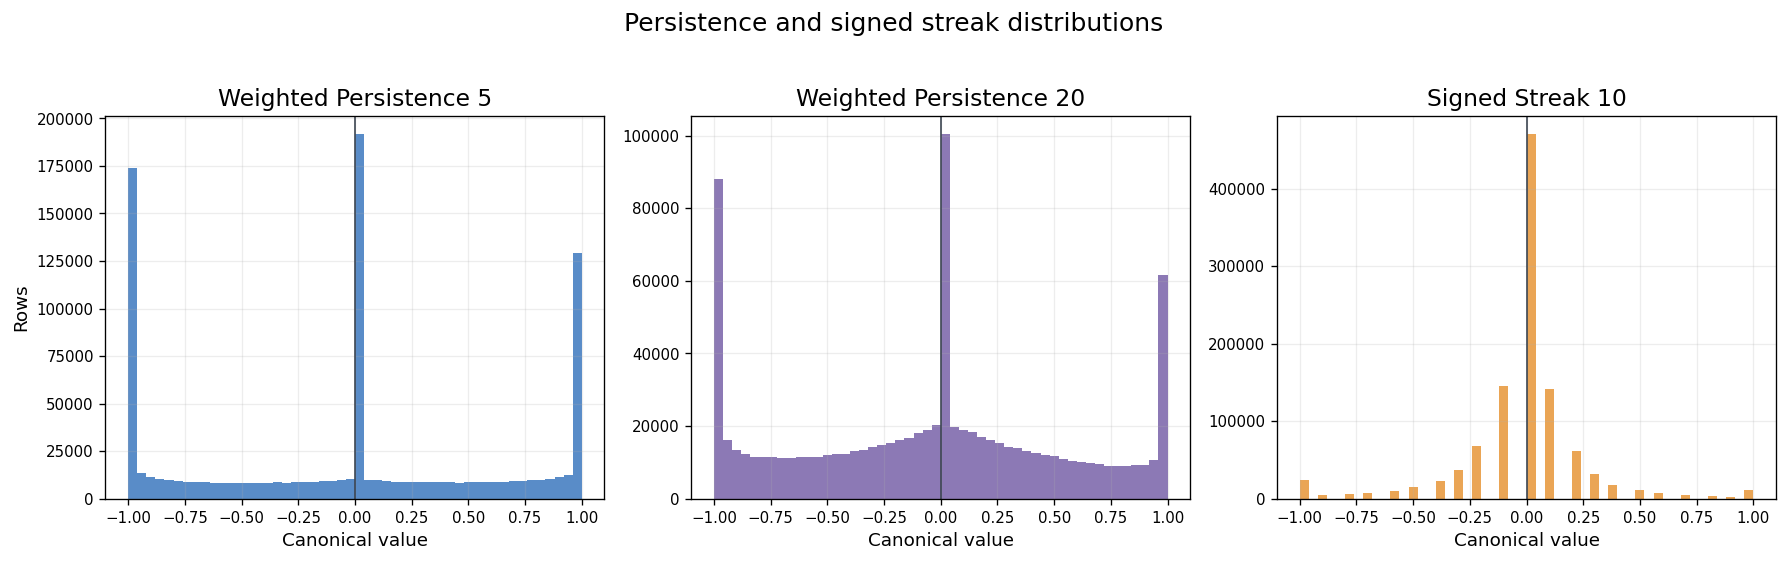

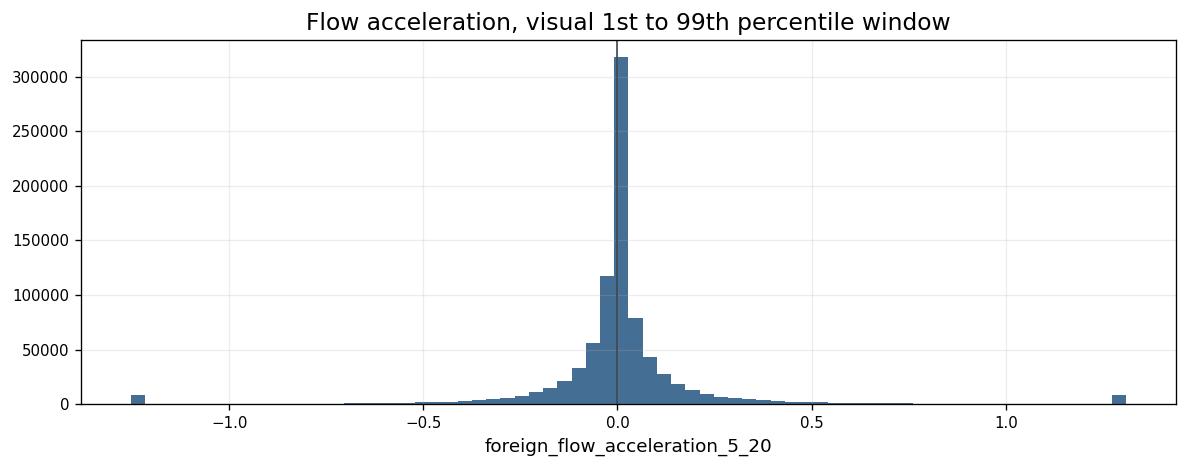

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for column, color, ax in [("foreign_weighted_persistence_5", BLUE, axes[0]), ("foreign_weighted_persistence_20", PURPLE, axes[1]), ("foreign_signed_streak_10", ORANGE, axes[2])]:
    values = panel[column].dropna()
    ax.hist(values, bins=50, color=color, alpha=0.8)
    ax.axvline(0, color=GRAY, lw=1)
    ax.set_title(column.replace("foreign_", "").replace("_", " ").title())
    ax.set_xlabel("Canonical value")
axes[0].set_ylabel("Rows")
plt.suptitle("Persistence and signed streak distributions", y=1.03, fontsize=15)
plt.tight_layout()
plt.show()

acceleration = panel["foreign_flow_acceleration_5_20"].dropna()
visual_acceleration = acceleration.clip(acceleration.quantile(0.01), acceleration.quantile(0.99))
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(visual_acceleration, bins=70, color=BLUE_DARK, alpha=0.8)
ax.axvline(0, color=GRAY, lw=1)
ax.set_title("Flow acceleration, visual 1st to 99th percentile window")
ax.set_xlabel("foreign_flow_acceleration_5_20")
plt.tight_layout()
plt.show()


## 9. Historical percentile

The 120-session historical percentile uses the canonical Representation V2 field. A value of 0.5 is a neutral reference for the historical rank, not a trading threshold or a claim of expected return.


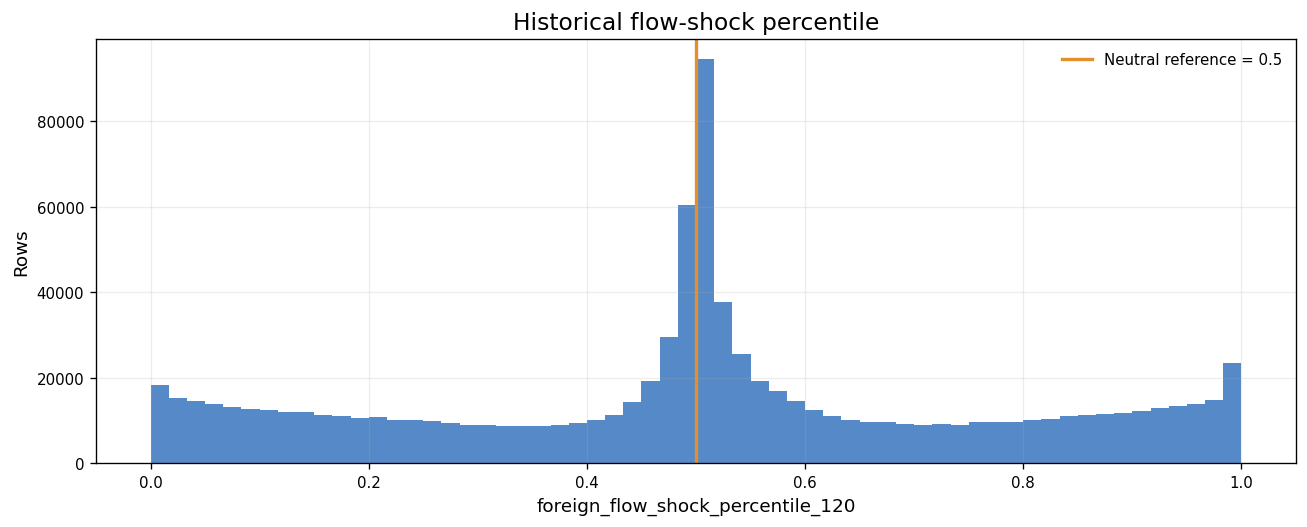

,statistic,value
0,count,899158.000000
1,median,0.500000
2,exact zero,0.010768
3,exact one,0.010306


In [10]:
percentile = panel["foreign_flow_shock_percentile_120"].dropna()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(percentile, bins=60, color=BLUE, alpha=0.82)
ax.axvline(0.5, color=ORANGE, lw=2, label="Neutral reference = 0.5")
ax.set_title("Historical flow-shock percentile")
ax.set_xlabel("foreign_flow_shock_percentile_120")
ax.set_ylabel("Rows")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
display(pd.DataFrame({"statistic": ["count", "median", "exact zero", "exact one"], "value": [len(percentile), percentile.median(), (percentile == 0).mean(), (percentile == 1).mean()]}))


## 10. Cross-sectional rank

Cross-sectional ranks are shown with the same neutral 0.5 reference. They are restricted by the accepted causal primary-liquid reconstruction and should not be read as a score or a future-return forecast.


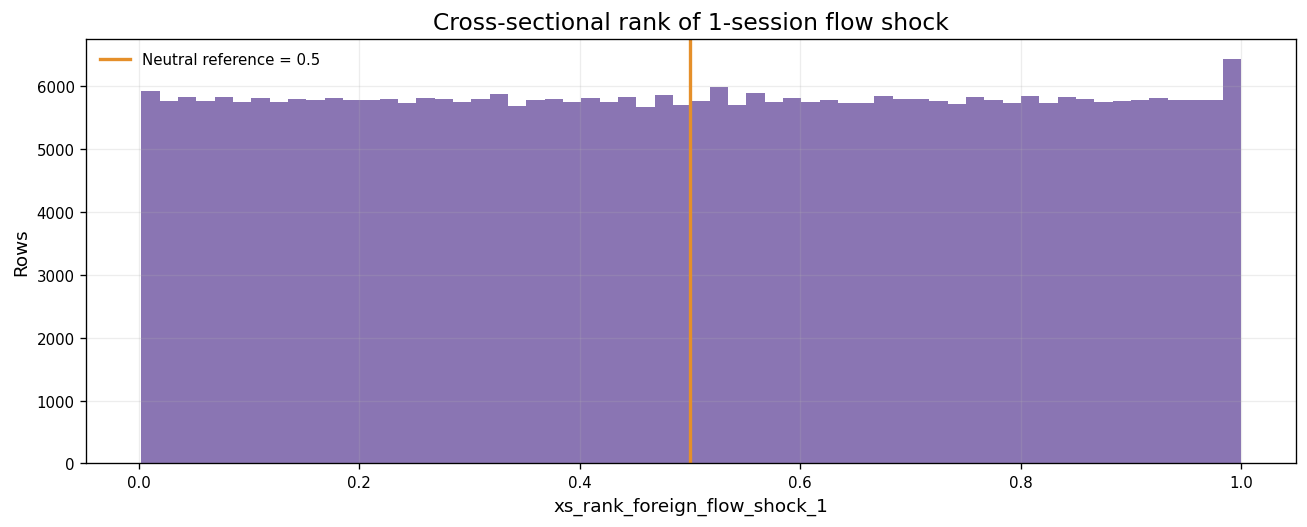

,statistic,value
0,count,347837.000000
1,median,0.501880
2,minimum,0.002309
3,maximum,1.000000


In [11]:
rank_values = panel["xs_rank_foreign_flow_shock_1"].dropna()
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist(rank_values, bins=60, color=PURPLE, alpha=0.82)
ax.axvline(0.5, color=ORANGE, lw=2, label="Neutral reference = 0.5")
ax.set_title("Cross-sectional rank of 1-session flow shock")
ax.set_xlabel("xs_rank_foreign_flow_shock_1")
ax.set_ylabel("Rows")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
display(pd.DataFrame({"statistic": ["count", "median", "minimum", "maximum"], "value": [len(rank_values), rank_values.median(), rank_values.min(), rank_values.max()]}))


## 11. Flow-price divergence

The divergence fields combine contemporaneous flow and price context over their stated windows. The figure is a descriptive association view only. It does not use future returns, does not backtest, and does not establish causality.


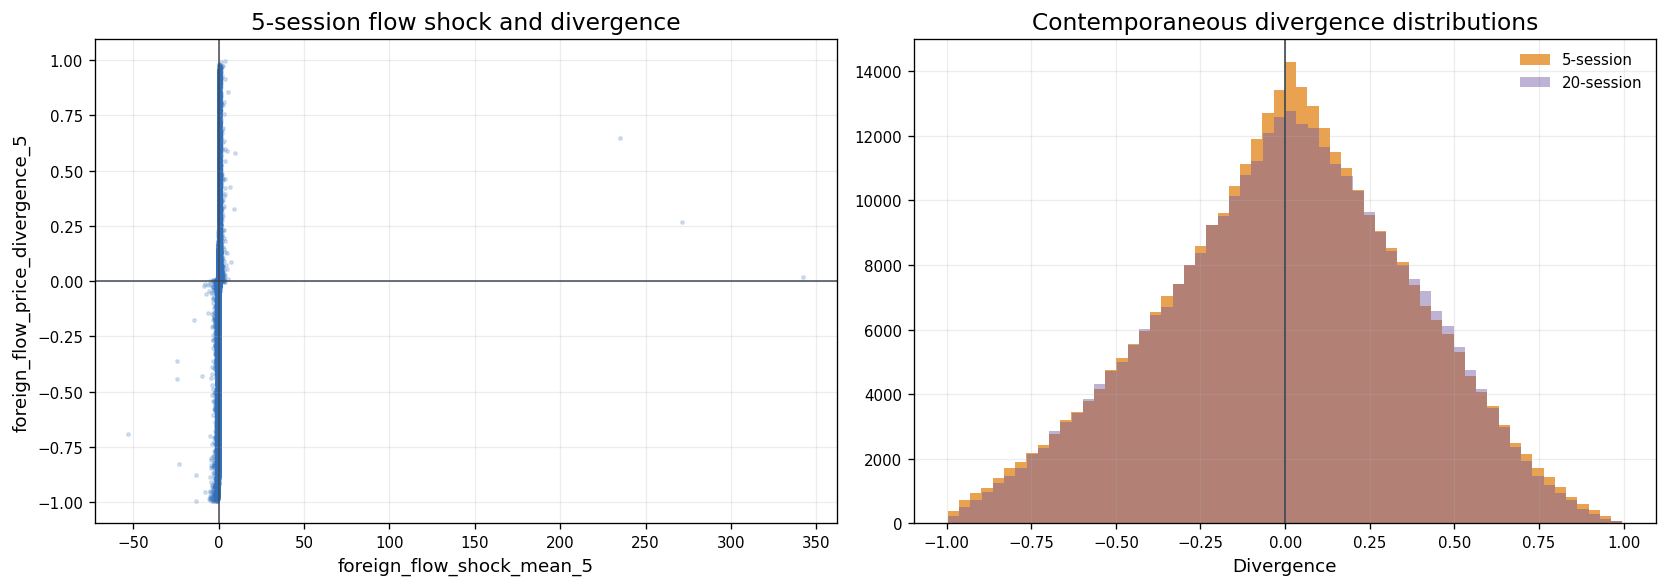

The scatter is a display sample of 100,000 rows from 346,420 valid contemporaneous rows. No future outcome is joined.

In [12]:
divergence_view = panel[["foreign_flow_shock_mean_5", "foreign_flow_price_divergence_5", "foreign_flow_price_divergence_20"]].dropna(subset=["foreign_flow_shock_mean_5", "foreign_flow_price_divergence_5"])
plot_view = divergence_view.sample(min(100_000, len(divergence_view)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(plot_view["foreign_flow_shock_mean_5"], plot_view["foreign_flow_price_divergence_5"], s=4, alpha=0.18, color=BLUE)
axes[0].axhline(0, color=GRAY, lw=0.9)
axes[0].axvline(0, color=GRAY, lw=0.9)
axes[0].set_title("5-session flow shock and divergence")
axes[0].set_xlabel("foreign_flow_shock_mean_5")
axes[0].set_ylabel("foreign_flow_price_divergence_5")
axes[1].hist(panel["foreign_flow_price_divergence_5"].dropna(), bins=60, color=ORANGE, alpha=0.82, label="5-session")
axes[1].hist(panel["foreign_flow_price_divergence_20"].dropna(), bins=60, color=PURPLE, alpha=0.45, label="20-session")
axes[1].axvline(0, color=GRAY, lw=1)
axes[1].set_title("Contemporaneous divergence distributions")
axes[1].set_xlabel("Divergence")
axes[1].legend(frameon=False)
plt.tight_layout()
plt.show()
display(Markdown(f"The scatter is a display sample of {len(plot_view):,} rows from {len(divergence_view):,} valid contemporaneous rows. No future outcome is joined."))


## 12. Config-driven ticker drilldown

Change `TICKER` in the configuration cell to inspect another ticker. This view remains historical and descriptive.

`IHSG_CONTEXT_UNAVAILABLE`: no continuous, canonical, date-aligned local IHSG series was accepted, so the ticker drilldown does not show an IHSG rebased comparison.

**IHSG_CONTEXT_UNAVAILABLE**. Local inspection found only date-sparse official IDX index snapshots and month fragments, plus synthetic test fixtures. No continuous, canonical, date-aligned IHSG series is accepted for this exploratory archive. No ticker versus IHSG comparison is plotted.

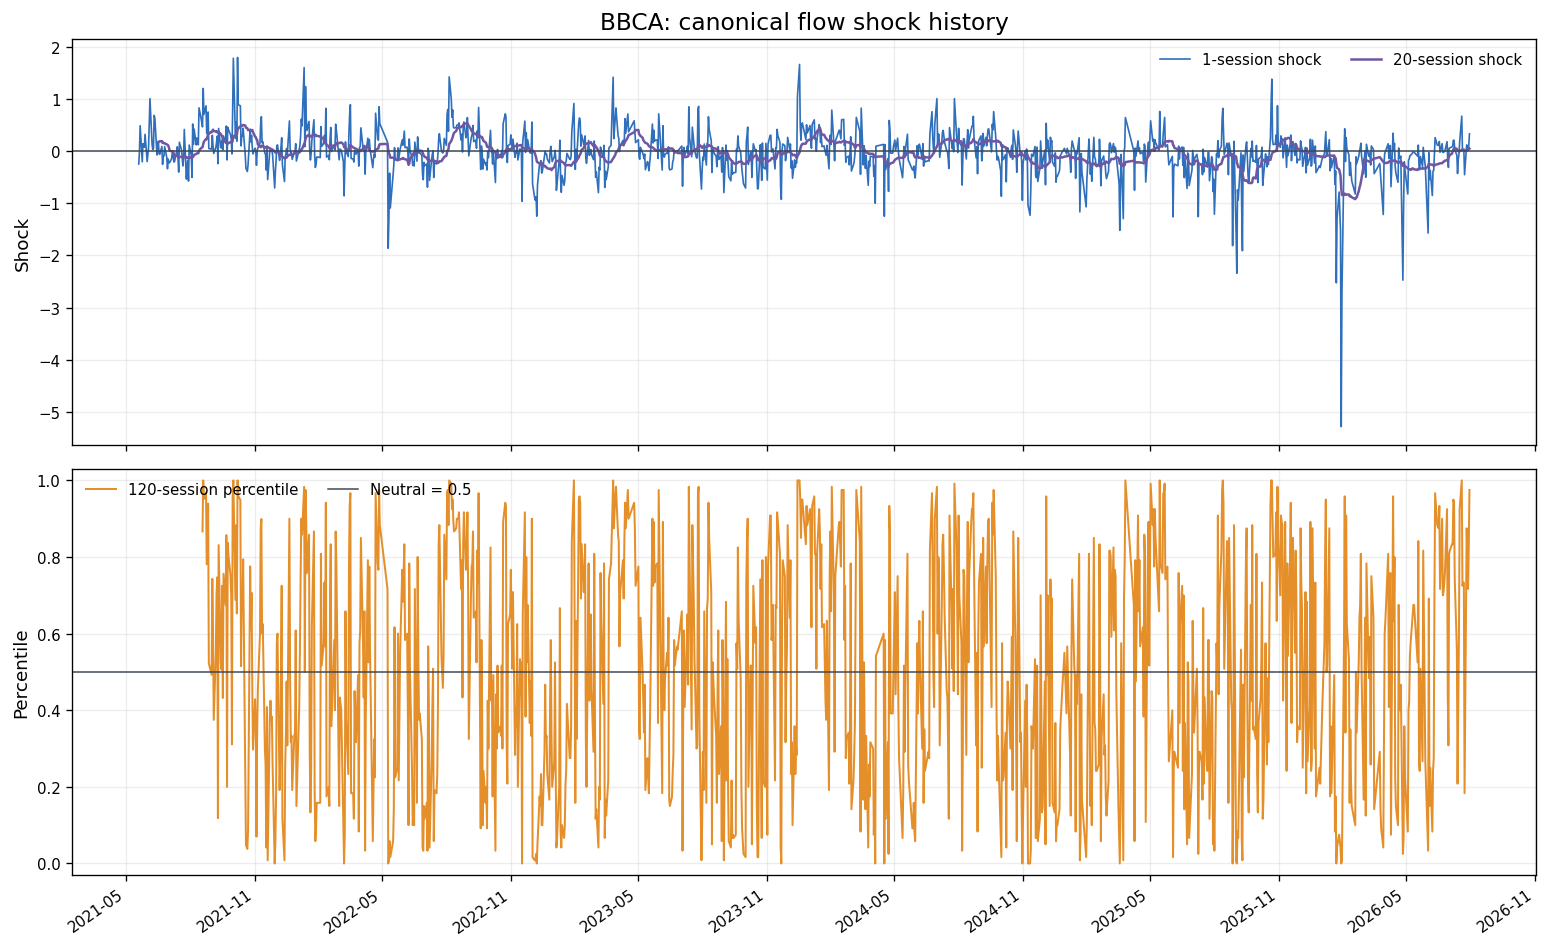

,feature_session,flow_through_session,close,regular_market_value,foreign_net,foreign_flow_shock_1,foreign_flow_shock_percentile_120,xs_rank_foreign_flow_shock_1
1090941,2026-07-16,2026-07-15,6125.0,8.637716e+11,-10111100.0,-0.055067,0.600000,0.383117
1091904,2026-07-17,2026-07-16,6225.0,5.814061e+11,30176200.0,0.168765,0.925000,0.806557
1092867,2026-07-20,2026-07-17,6475.0,2.042512e+12,109203900.0,0.669993,1.000000,0.990066
1093830,2026-07-21,2026-07-20,6475.0,1.945091e+12,2097300.0,0.012867,0.725000,0.592715
1094793,2026-07-22,2026-07-21,6525.0,9.486642e+11,2670500.0,0.016511,0.733333,0.557756
1095756,2026-07-23,2026-07-22,6500.0,7.244705e+11,2703900.0,0.016653,0.733333,0.727575
1096719,2026-07-24,2026-07-23,6275.0,1.315503e+12,-76216200.0,-0.453162,0.183333,0.110738
1097682,2026-07-27,2026-07-24,6275.0,1.187569e+12,19973100.0,0.118755,0.875000,0.856187
1098645,2026-07-28,2026-07-27,6300.0,7.838218e+11,15346900.0,0.086864,0.816667,0.821549
1099608,2026-07-29,2026-07-28,6225.0,7.686122e+11,2999200.0,0.017825,0.716667,0.755932


In [13]:
display(Markdown(f"**{IHSG_CONTEXT_STATUS}**. {IHSG_CONTEXT_REASON} No ticker versus IHSG comparison is plotted."))

ticker_view = panel.loc[panel["ticker"] == TICKER].sort_values("feature_session").copy()
if ticker_view.empty: raise ValueError(f"Ticker {TICKER} is not present in the Representation V2 artifact")

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
axes[0].plot(ticker_view["feature_session"], ticker_view["foreign_flow_shock_1"], color=BLUE, lw=1.0, label="1-session shock")
axes[0].plot(ticker_view["feature_session"], ticker_view["foreign_flow_shock_mean_20"], color=PURPLE, lw=1.5, label="20-session shock")
axes[0].axhline(0, color=GRAY, lw=0.9)
axes[0].set_title(f"{TICKER}: canonical flow shock history")
axes[0].set_ylabel("Shock")
axes[0].legend(frameon=False, ncol=2)
axes[1].plot(ticker_view["feature_session"], ticker_view["foreign_flow_shock_percentile_120"], color=ORANGE, lw=1.2, label="120-session percentile")
axes[1].axhline(0.5, color=GRAY, lw=0.9, label="Neutral = 0.5")
axes[1].set_ylabel("Percentile")
axes[1].set_ylim(-0.03, 1.03)
axes[1].legend(frameon=False, ncol=2)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

display(ticker_view[["feature_session", "flow_through_session", "close", "regular_market_value", "foreign_net", "foreign_flow_shock_1", "foreign_flow_shock_percentile_120", "xs_rank_foreign_flow_shock_1"]].tail(12))


## 13. What looks interesting?

The table separates observable patterns from interpretation. It intentionally does not turn descriptive structure into a strategy claim.


In [14]:
interesting = pd.DataFrame([
    {"observation": "Shock tails", "evidence": f"{int((shock.absolute_shock > 5).sum()):,} rows have |shock| > 5", "neutral_interpretation": "Large normalized flow changes merit provenance and data-quality review; they are not causal signals."},
    {"observation": "Availability", "evidence": f"{audit_summary['availability']['fully_available_rows']:,} fully available, {audit_summary['availability']['partial_rows']:,} partial", "neutral_interpretation": "Coverage varies by ticker and session; missingness must remain explicit."},
    {"observation": "Historical percentile", "evidence": f"median = {percentile.median():.4f}", "neutral_interpretation": "The distribution is centered near its historical reference by construction of the rank view."},
    {"observation": "Repeated names", "evidence": ", ".join(case_names), "neutral_interpretation": "These names contain repeated extreme observations in this archive; mechanism is unresolved here."},
    {"observation": "Divergence", "evidence": f"{len(divergence_view):,} valid contemporaneous rows", "neutral_interpretation": "Flow and price context can disagree contemporaneously; no future-return conclusion is available."},
])
display(interesting)

display(Markdown("**Research boundary:** Foreign Flow V2 is an outcome-blind representation and remains a research artifact. This notebook does not claim alpha, live production evidence, historical portfolio reconstruction, or model promotion."))


,observation,evidence,neutral_interpretation
0,Shock tails,"4,809 rows have |shock| > 5",Large normalized flow changes merit provenance...
1,Availability,"318,592 fully available, 783,240 partial",Coverage varies by ticker and session; missing...
2,Historical percentile,median = 0.5000,The distribution is centered near its historic...
3,Repeated names,"FUJI, CASA, JGLE, PSKT",These names contain repeated extreme observati...
4,Divergence,"346,420 valid contemporaneous rows",Flow and price context can disagree contempora...


**Research boundary:** Foreign Flow V2 is an outcome-blind representation and remains a research artifact. This notebook does not claim alpha, live production evidence, historical portfolio reconstruction, or model promotion.